Text(0, 0.5, 'Amplitude')

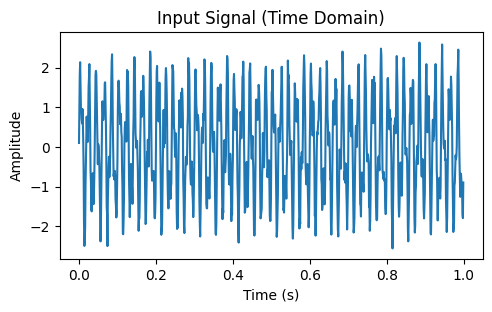

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Set random seed for reproducibility
np.random.seed(42)

# 1. Generate a synthetic signal (sum of two sine waves)
fs = 1000  # Sampling frequency (Hz)
t = np.linspace(0, 1, fs, endpoint=False)  # Time vector for 1 second
freq1, freq2 = 50, 120  # Frequencies of sine waves (Hz)
signal_input = 1.5 * np.sin(2 * np.pi * freq1 * t) + 0.8 * np.sin(2 * np.pi * freq2 * t)

# Add some noise
noise = 0.2 * np.random.normal(0, 1, t.shape)
signal_input += noise

# 2. Fourier Transform (Continuous-time approximation using numerical integration)

# Plotting the results
plt.figure(figsize=(12, 10))

# Plot the input signal
plt.subplot(3, 2, 1)
plt.plot(t, signal_input)
plt.title("Input Signal (Time Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")


Text(0, 0.5, 'Magnitude')

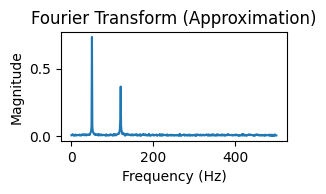

In [15]:
def fourier_transform(signal, t, freqs):
    dt = t[1] - t[0]
    ft = np.zeros(len(freqs), dtype=complex)
    for i, f in enumerate(freqs):
        ft[i] = np.sum(signal * np.exp(-2j * np.pi * f * t)) * dt
    return ft

freqs = np.linspace(0, fs/2, 500)  # Frequency range up to Nyquist
ft_result = fourier_transform(signal_input, t, freqs)
ft_magnitude = np.abs(ft_result)



# Plot FT
plt.subplot(3, 2, 2)
plt.plot(freqs, ft_magnitude)
plt.title("Fourier Transform (Approximation)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")


Text(0, 0.5, 'Magnitude')

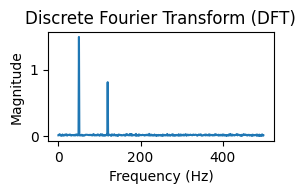

In [16]:


# 3. Discrete Fourier Transform (DFT) from scratch
def dft(signal):
    N = len(signal)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j * np.pi * k * n / N)
    return np.dot(e, signal)

dft_result = dft(signal_input)
dft_freqs = np.fft.fftfreq(len(signal_input), 1/fs)[:len(signal_input)//2]
dft_magnitude = np.abs(dft_result)[:len(signal_input)//2] * 2 / len(signal_input)



# Plot DFT
plt.subplot(3, 2, 3)
plt.plot(dft_freqs, dft_magnitude)
plt.title("Discrete Fourier Transform (DFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")




Text(0, 0.5, 'Magnitude')

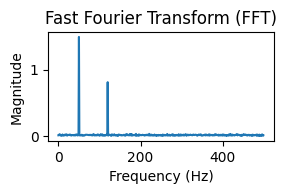

In [17]:
# 4. Fast Fourier Transform (FFT) using NumPy
fft_result = np.fft.fft(signal_input)
fft_freqs = np.fft.fftfreq(len(signal_input), 1/fs)[:len(signal_input)//2]
fft_magnitude = np.abs(fft_result)[:len(signal_input)//2] * 2 / len(signal_input)

# Plot FFT
plt.subplot(3, 2, 4)
plt.plot(fft_freqs, fft_magnitude)
plt.title("Fast Fourier Transform (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

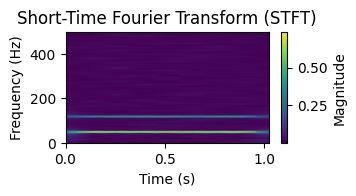

In [18]:

# 5. Short-Time Fourier Transform (STFT) using SciPy
f_stft, t_stft, Zxx = signal.stft(signal_input, fs=fs, nperseg=256)

# Plot STFT (Spectrogram)
plt.subplot(3, 2, 5)
plt.pcolormesh(t_stft, f_stft, np.abs(Zxx), shading='gouraud')
plt.title("Short-Time Fourier Transform (STFT)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Magnitude")

plt.tight_layout()
plt.show()